<a href="https://colab.research.google.com/github/Valeriy1990/Else/blob/main/17_1_%D0%9F%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0_%D0%BF%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

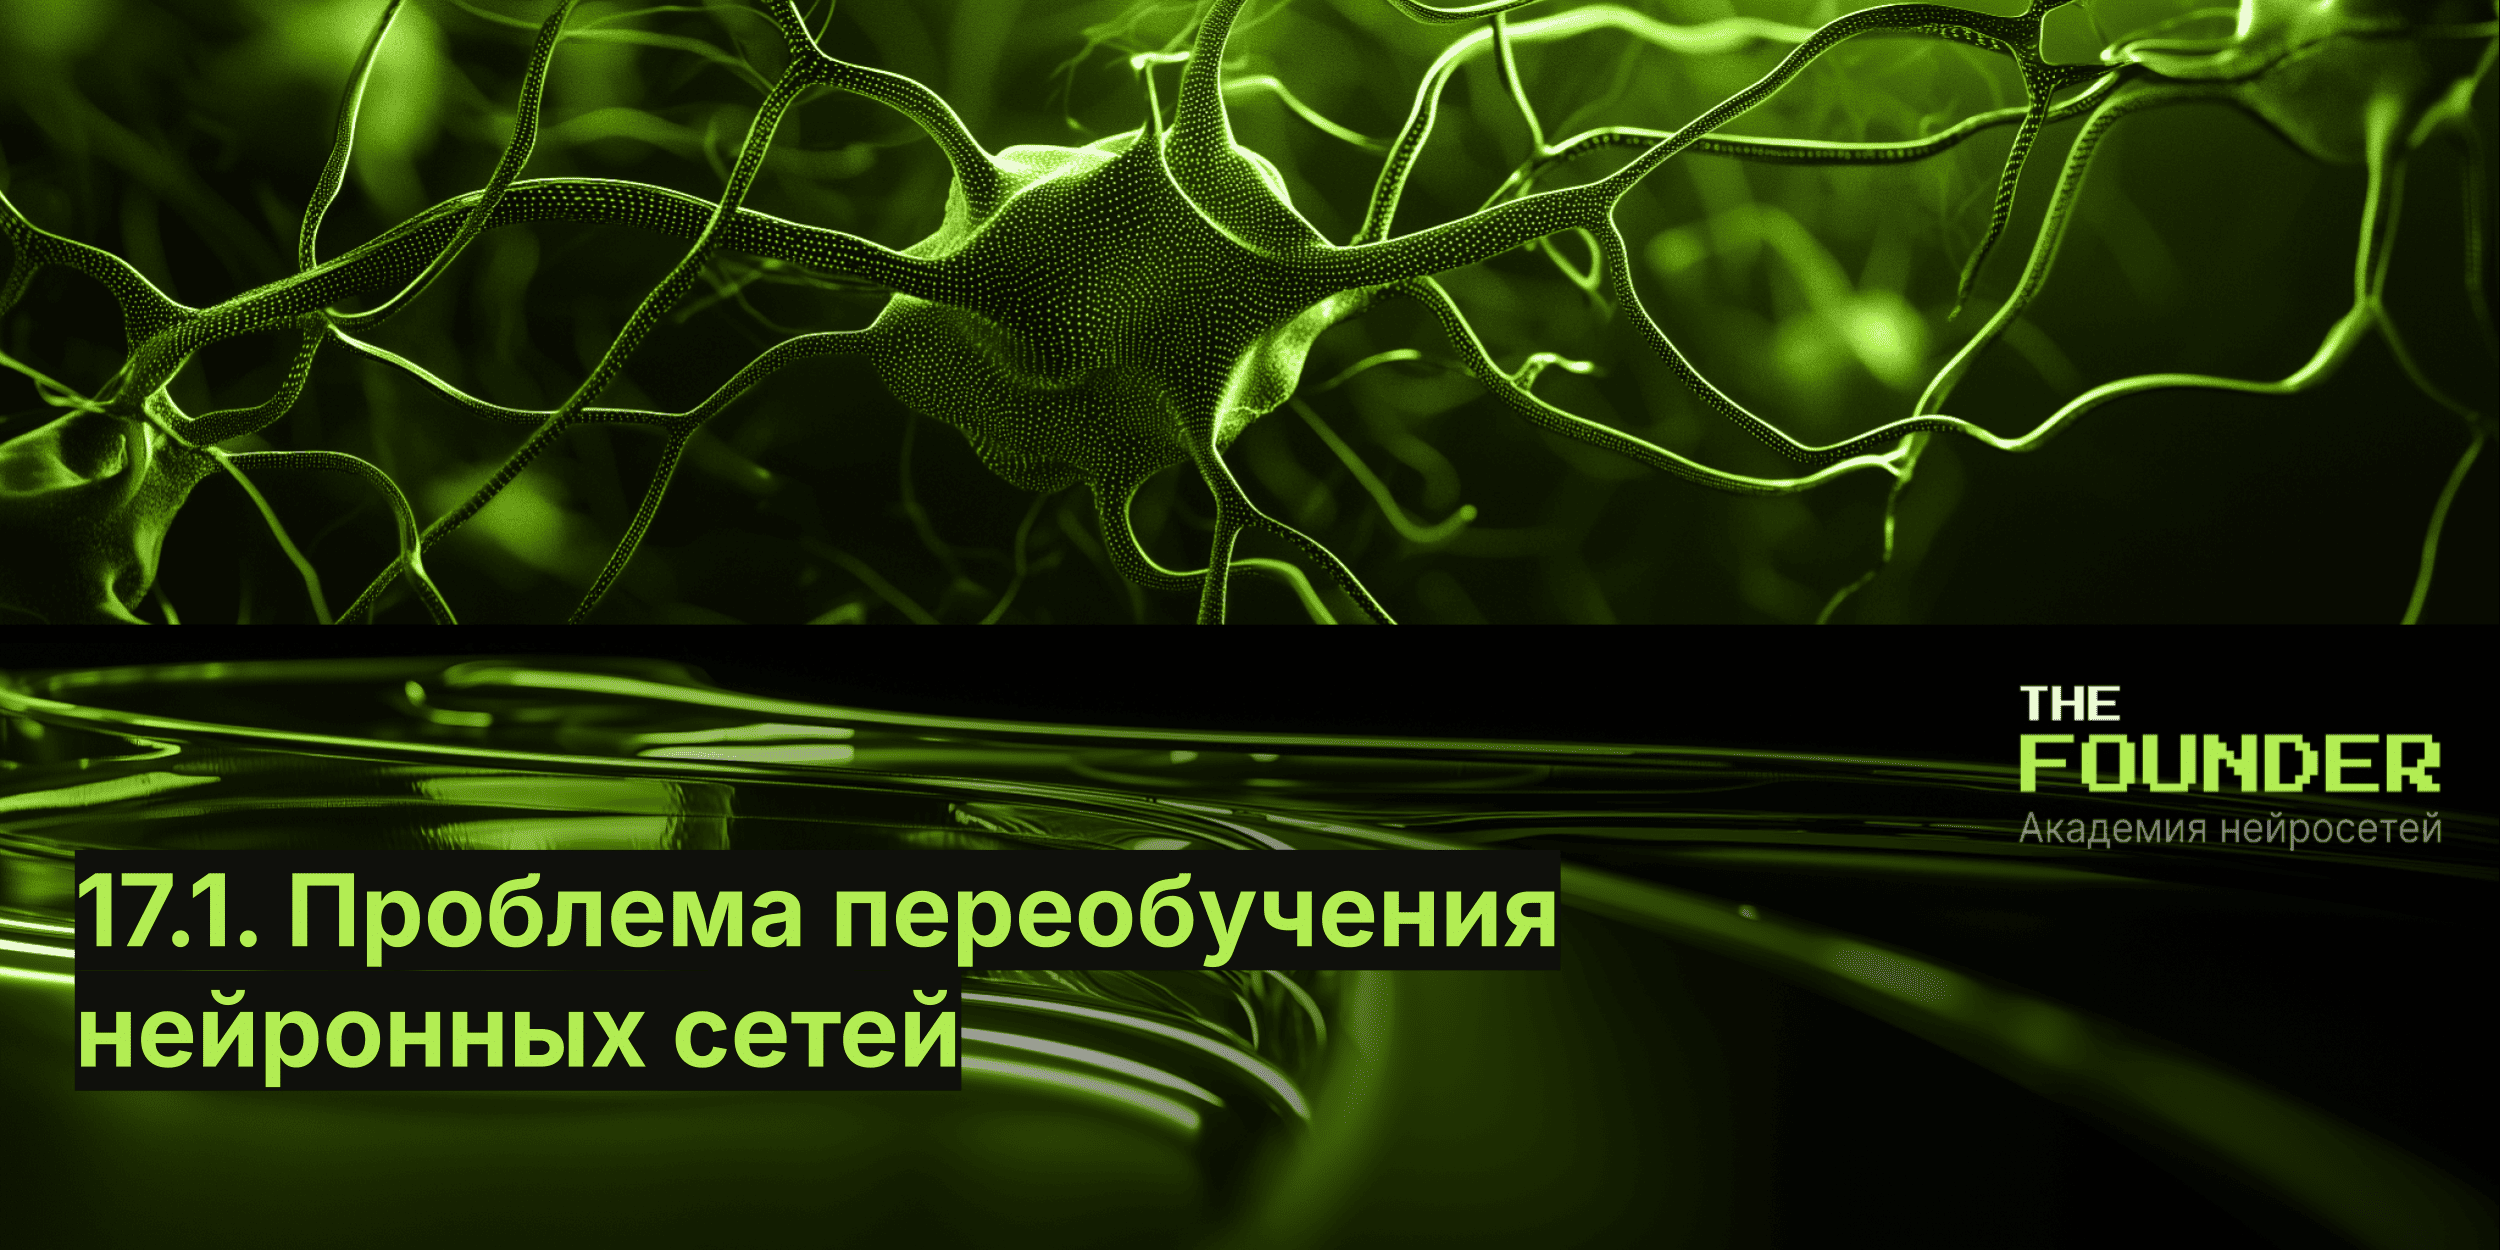

**Навигация по уроку**

1. Проблема переобучения нейронных сетей
2. [Методы оптимизации и регуляризации НС](https://colab.research.google.com/drive/1VWkA2xBTwWreo3DTdiMkio-RfQIvlXBl)
3. [Универсальный алгоритм машинного обучения](https://colab.research.google.com/drive/1hK-5MC4eApd1-tRMppY9X9RLUYeMqG4q)
4. [Домашняя работа](https://colab.research.google.com/drive/1e0K_XldGH5ac4Y2N7rbK56rEJx0vXu3C)

## Тренировочные, проверочные и контрольные наборы данных

### Зачем делить выборки?

В прошлых уроках мы выяснили причину, почему нельзя оценивать качество моделей по тем же данным, на которых производилось обучение: спустя всего несколько эпох в моделях мог возникнуть эффект переобучения. Т.е. качество прогнозирования на данных, которые не участвовали в обучении, перестает возрастать или даже начинает ухудшаться, тогда как на тренировочных данных качество прогноза всегда растет в ходе обучения.

> Цель машинного обучения состоит в создании обобщающих моделей, дающих качественный прогноз на данных, не участвовавших в обучении, а переобучение является главным препятствием к ее достижению.

Вы можете контролировать только то, что наблюдаете, поэтому важно иметь возможность надежно оценивать качество обобщения вашей модели.

**Поэтому наша главная цель на текущем уроке научиться бороться с проблемой переобучения и достижения максимальной обобщенности!**

Чтобы понять, а есть ли у нас проблема переобучения, мы сначала должны определиться, как мы оцениваем модель.

А оценка модели всегда сводится к делению доступных данных на три набора:
тренировочный, проверочный и тестовый (он же контрольный).

Нашу модель мы обучаем на тренировочных данных и оцениваем с помощью проверочных. Когда же мы создадим окончательную модель, то должны ее протестировать с применением контрольных данных.

Возможно, у вас уже возник справедливый вопрос: почему бы не использовать только два набора — тренировочный и контрольный? В этом случае можно было бы обучать модель на тренировочных данных и тестировать на контрольных. Ведь так намного проще!

Причина в том, что процесс конструирования модели всегда связан с настройкой
ее параметров. Далее мы будем эти параметры называть гиперпараметры. Под гиперпараметрами обычно подразумевают: выбор количества слоев, их размерности. Такое название вводиться для того, чтобы отличать их от весовых коэффициентов, которые по сути тоже являются параметрами модели.

Для настройки модели в качестве сигнала обратной связи используются проверочные данные. Фактически настройка сама является разновидностью обучения: поиск более удачной конфигурации в некотором пространстве параметров. Как результат, настройка конфигурации модели по качеству прогнозирования на проверочных данных может быстро привести к переобучению на этих данных, даже при том, что модель никогда напрямую не обучается на них.

Главной причиной этого является так называемая утечка информации. Каждый раз, настраивая гиперпараметр модели и опираясь на качество прогноза по проверочным данным, вы допускаете просачивание в модель некоторой информации из этих данных. Если сделать это только один раз для одного параметра, в модель просочится небольшой объем информации и проверочный набор данных останется надежным оценщиком качества модели. Однако если повторить настройку много раз — выполняя эксперимент, оценивая модель на проверочных данных и корректируя ее по результатам — в модель будет просачиваться все больший объем информации о проверочном наборе данных.

В конце концов вы получите модель, искусственно настроенную на достижение
высокого качества прогнозирования по проверочным данным, потому что именно
на этих данных вы ее оптимизировали. Однако истинной целью является качество
прогнозирования на совершенно новых данных, не на проверочных, поэтому для
оценки качества модели следует использовать отдельный набор данных, никак не участвующий в обучении, — контрольный набор. Ваша модель не должна иметь доступа ни к какой информации из контрольного набора, даже косвенно. Если какие-то настройки модели выполнить на основе оценки качества прогнозирования по контрольным данным, ваша оценка обобщенности модели будет неточной.

Деление данных на тренировочный, проверочный и контрольный наборы может показаться простой задачей, тем не менее есть ряд приемов ее решения, которые
могут пригодиться при ограниченном объеме исходных данных.


**Рассмотрим классические методы оценки:**
* проверка с простым расщеплением выборки (*hold-out validation*);
* перекрестная проверка по K блокам (*K-fold validation*)

Перекрёстная проверка, или как её чаще называют, кросс-валидация, имеет различные вариации, например: итерационная проверка по K блокам с перемешиванием (*iterated K-fold validation with shuffling*).

### Проверка с простым расщеплением выборки

Некоторая часть данных выделяется в контрольный набор. Обучение производится
на оставшихся данных, а оценка качества — на контрольных. Как уже говорилось, для предотвращения утечек информации модель не должна настраиваться по результатам прогнозирования на контрольных данных, поэтому требуется также зарезервировать отдельный проверочный набор.


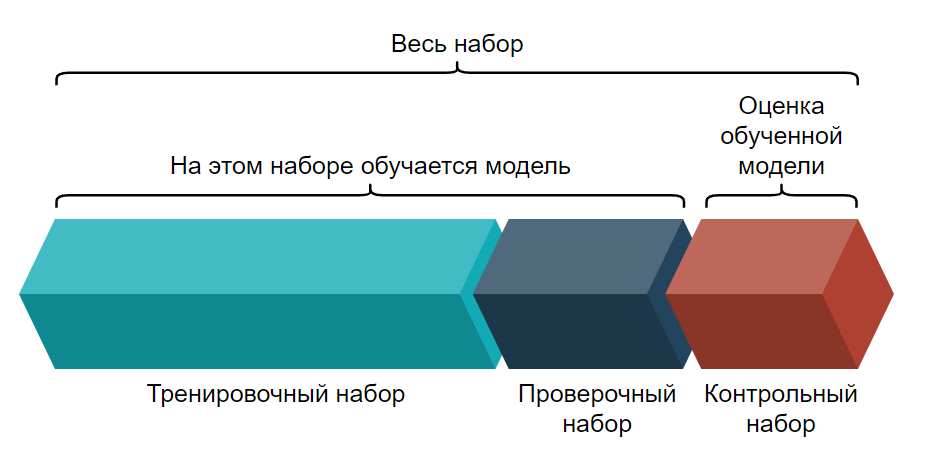

Рассмотрим варианты расщепления выборок на примере известного нам датасета - MNIST. Сначала загрузим датасет:

In [ ]:
# загрузка всего датасет MNIST
from tensorflow.keras.datasets import mnist

# запись в переменные нужных нам частей
(x, y), (x1 , y1) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


При загрузке MNIST мы сразу получили два набора данных: `(x, y)` - тренировочный, состоящий из 60000 изображений и контрольный `(x1, y1)` - из 10000.

Давайте возьмем только набор `(x, y)` и на его примере рассмотрим, как можно делить выборки:  

#### Вариант 1. Срез

Это самый простой способ и он не требует использовать сторонние функции. С помощью среза мы можем разделить наш датасет на любое количество выборок.

У этого метода есть один большой минус - данные отсекаются большими блоками, без перемешивания, как они были расположены в первоначальной выборке. А значит, если в выборке существовала, какая-либо зависимость, например, временная, то она скажется и на процессе обучения. Либо, если данные накапливались постепенно, то в контрольную выборку попадут актуальные данные, а в тренировочную, уже достаточно устаревшие.

Делить выборки можно в любых пропорциях, например, `80% / 10% / 10%`, т. е.:

* тренировочная (или обучающая) выборка (x_train) составит: $60000 * 0.8 = 48000$
* проверочная (или валидационная) выборка (x_val) составит: $60000 * 0.1 = 6000$
* контрольная (или тестовая) выборка (x_test) составит: $60000 * 0.1 = 6000$

In [ ]:
x_train = x[:48000]
x_val   = x[48000:54000]
x_test  = x[54000:]

print('Тренировочная выборка (изображения):', x_train.shape)
print('Проверочная выборка   (изображения):', x_val.shape)
print('Контрольная выборка   (изображения):', x_test.shape)

Тренировочная выборка (изображения): (48000, 28, 28)
Проверочная выборка   (изображения): (6000, 28, 28)
Контрольная выборка   (изображения): (6000, 28, 28)


То же самое необходимо проделать и для меток:

In [ ]:
y_train = y[:48000]
y_val   = y[48000:54000]
y_test  = y[54000:]

print('Тренировочная выборка (метки):', y_train.shape)
print('Проверочная выборка   (метки):', y_val.shape)
print('Контрольная выборка   (метки):', y_test.shape)

Тренировочная выборка (метки): (48000,)
Проверочная выборка   (метки): (6000,)
Контрольная выборка   (метки): (6000,)


Мы вырезаем одни и те же части наборов для изображений и меток, а значит их соответствие сохраняется:

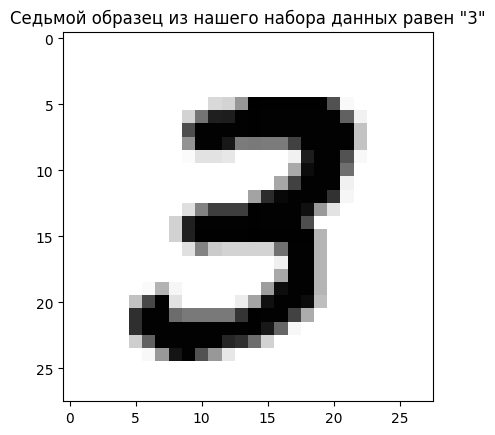

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

digit = x_train[7]
fig, ax = plt.subplots(1,1)
ax.set_title(f'Седьмой образец из нашего набора данных равен "{y_train[7]}"')
ax.imshow(digit, cmap=plt.cm.binary)
plt.show()

#### Вариант 2. Маска

Вариант с маской позволяет выбрать в каждую выборку случайные, перемешанные данные. В этом его несомненный плюс.

In [ ]:
import random
import numpy as np

# Процент, который выделяем в тестовую выборку
split_test = 0.2

# Процент, который выделяем в проверочную выборку
split_val = 0.2

# Список из случайных значений от 0 до 1, длиной равной х
mask_list = np.random.sample(x.shape[0])

# Создаём маску True-False для создания проверочной выборки
# Проведем над нашим списком логические операции
mask_test = mask_list >= 1 - split_test # все элементы списка большие или равные 0.8 преобразуются в True, остальные в False

# все элементы списка меньшие 0.6 преобразуются в True, остальные в False
mask_train = (1 - split_test - split_val) > mask_list

# все оставшиеся элементы списка True, вошедшие в mask_test или mask_train - устанавливаем в False
# `~` - означает инверсию, логическое НЕ. Где было False станет True и наоборот
# `|` - логическое ИЛИ, объединяет все True в обоих списках, сохраняя длину списка.
mask_val = ~(mask_test | mask_train) #


print(f'Длина тренировочной выборки: {len(x[mask_train])}')
print(f'Длина проверочной выборки: {len(x[mask_val])}')
print(f'Длина контрольной выборки: {len(x[mask_test])}')

Длина тренировочной выборки: 36268
Длина проверочной выборки: 11882
Длина контрольной выборки: 11850


Это очень важный прием расщепления выборок, который должен быть в арсенале каждого нейронщика, а поэтому давайте рассмотрим его поэтапно с выводом промежуточных результатов для небольшой выборки всего из 10 чисел:

Шаг 1. Создадим диапазон от 0 до 9 в качестве простого датасета.

In [ ]:
xs = np.asarray(range(10))

Шаг 2. Определим в процентном соотношении размер контрольной и проверочной выборок.

In [ ]:
# Процент, который выделяем в тестовую выборку
split_test = 0.2

# Процент, который выделяем в проверочную выборку
split_val = 0.2

Шаг 3. Определим список случайных значений от 0 до 1, такой же длины, что и наш датасет.

In [ ]:
# Список из случайных значений от 0 до 1, длиной равной хs
mask_list = np.random.sample(xs.shape[0])
print(mask_list)

[0.90642307 0.88663906 0.04397353 0.28586028 0.91291299 0.85322914
 0.32796037 0.72919341 0.41919813 0.36257348]


Применяя данный прием, мы ожидаем, что наши случайные числа будут равно распределены на всём диапазоне списка. Для нашего коротко списка это условие, конечно, не будет выполняться. Однако с ростом датасета, теория вероятности будет работать на нас, и список будет становиться равнораспределенным. Это означает, что если в нашем списке мы выберем все числа, которые, например, больше 0.23 и меньше или равны 0.33, то таких чисел для равнораспределенного списка будет 10% от длины списка. Этим свойством мы дальше и воспользуемся.

Шаг 4. Создадим булеву маску (True/False) для контрольных образцов

In [ ]:
mask_test = mask_list >= 1 - split_test
print(mask_test)

[ True  True False False  True  True False False False False]


В результате бинарной операции сравнения нашего списка с одним единственным числовым значением ($>=0.8$), мы получаем новый список, где для всех значений, для которых выполняется условие $x_i>=0.8$, установлено значение True и, соответственно, False, если условие не выполняется.

Шаг 5. Создадим булеву маску (True/False) для тренировочных образцов. Принцип тот же, что и в шаге 4, только теперь помечаем True, только те значения списка, которые меньше $0.6$.

In [ ]:
mask_train = (1 - split_test - split_val) > mask_list
print(mask_train)

[False False  True  True False False  True False  True  True]


Шаг 6. Создадим булеву маску (True/False) для проверочных образцов. Так как мы уже создали маски для тренировочной и контрольной выборок, то нам необходимо выбрать все остальные элементы датасета, и сделать из них маску. Проще всего это сделать объединением двух масок (логическое ИЛИ): тренировочной и контрольной. Далее к новой, объединенной маске применим операцию инверсии (логического НЕ) , то есть заменим True на False, а False на True. В итоге, мы получаем маску для проверочных образцов.

In [ ]:
mask_val = ~(mask_test | mask_train)
print(mask_val)

[False False False False False False False  True False False]


Шаг 7. Получение из маски выборок.

In [ ]:
print(f'Тренировочная выборка: {xs[mask_train]}')
print(f'Проверочная выборка:   {xs[mask_val]}')
print(f'Контрольная выборка:   {xs[mask_test]}')

Тренировочная выборка: [2 3 6 8 9]
Проверочная выборка:   [7]
Контрольная выборка:   [0 1 4 5]


Если бы данные были бы равнораспределенными, то мы бы получили по 2 значения для проверочной и контрольной выборок и 6 значений для тренировочной, однако, это не так. Поэтому данный метод для расщепления данных, мы используем только в том случае, если размер датасета достаточно большой.

#### Вариант 3. Библиотека sklearn

Уже знакомая нам библиотека `sklearn` содержит готовый метод `train_test_split` для расщепления данных.

Чтобы воспользоваться методом, сначала нам необходимо импортировать его:

In [ ]:
# импорт библиотеки
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, shuffle=True, random_state=42)

Функция имеет несколько аргументов:

* `x_data` и `y_data` – разделяемые наборы данных (здесь мы передаем x -  изображения, а y - метки, которые нам необходимо разделить);
* `test_size` – процент значений, которые пойдут в контрольную выборку;
* `shuffle` – нужно ли перемешивать данные, возможные значения True или False. Без перемешивания выборки будут сформированы в порядке следования примеров из датасета, что может привести к попаданию в тестовую выборку примеров только одного класса, либо более "свежие"  данные, чем в тренировочных.
* `random_state` – параметр воспроизводимости. Если его указать, то при повторном запуске данные будут перемешаны в том же порядке. Часто в примерах встречаются значения 0 или 42.

Функция возвращает:

* `x_train`, `x_test`, `y_train`, `y_test` – результаты работы функции, тренировочная и контрольная выборки.

In [ ]:
print('Тренировочная выборка изображений', len(x_train))
print('Тренировочная выборка меток', len(y_train))
print('Контрольная выборка изображений', len(x_test))
print('Контрольная выборка меток', len(y_test))

Тренировочная выборка изображений 54000
Тренировочная выборка меток 54000
Контрольная выборка изображений 6000
Контрольная выборка меток 6000


Возникает справедливый вопрос: а где же проверочная выборка?

Вы можете либо ещё раз использовать тренировочную выборку и воспользоваться ещё раз функцией `train_test_split`, тем самым выделить проверочную выборку, либо сформировать ее автоматически, как в следующем примере, в процессе обучения.

#### Вариант 4. Автоматическое выделение проверочной выборки в процессе обучения

У метода `fit()` есть удобный параметр `validation_split`, позволяющий отделить проверочные данные от тренировочных в процессе обучения.

```python
model.fit(x_train,
          y_train,
          batch_size=8,
          epochs=100,
          validation_split=0.2,
          verbose=1)
```


В качестве значения параметра мы передаем значение в процентном соотношении, т. е. какую часть данных выделить в проверочную выборку. Перед разделением данные в выборке перемешаны не будут. Поэтому рекомендуется предварительно перемешать их самостоятельно.


Таким образом мы рассмотрели простое расщепление выборки для обучения и оценки нашей модели. Это самый простой метод оценки, страдающий одним существенным недостатком: при небольшом объеме доступных данных проверочный и контрольный наборы могут содержать слишком мало образцов, чтобы считаться статистически репрезентативными. Это легко заметить: если разные случайные перестановки данных перед расщеплением дают сильно различающиеся оценки качества модели, значит, вы столкнулись именно с этой проблемой. Для ее преодоления были разработаны два других подхода: перекрестная проверка по K блокам
и итерационная проверка по K блокам с перемешиванием.

### Перекрестная проверка по K блокам

При использовании этого подхода данные разбиваются на $K$ блоков равного
размера. Для каждого блока $i$ производится обучение модели на остальных $K—1$
блоках и оценка на блоке $i$. Окончательная оценка рассчитывается как среднее $K$ промежуточных оценок.

Этот метод может пригодиться, когда качество модели
слишком сильно зависит от деления данных на тренировочный/контрольный наборы. Подобно проверке с простым расщеплением выборки, этот метод не
избавляет от необходимости использовать отдельный проверочный набор для
калибровки модели.


Перекрестную проверку по $K$ блокам или как её чаще называют K-fold  методом можно описать следующим алгоритмом:



1. Фиксируется некоторое целое число $K$. Чаще всего в диапазоне от 5 до 10. Главное чтобы число было меньше числа примеров в датасете.
2. Датасет разбивается на $K$ одинаковых частей. В последней части может быть меньше примеров, чем в остальных. Эти части называются `фолдами`. Отсюда и название метода.
3. Далее в цикле выполняются итераций, во время каждой из которых один фолд выступает в роли тестового множества, а остальные — в роли тренировочного.
4. Оценка модели производится либо усреднением
 получившихся тестовых результатов, либо измеряется на отложенном тестовом множестве, не участвовавшем в кросс-валидации.

Мы можем использовать кросс-валидацию для следующих целей:

1. Для прогнозирования на новых данных, которые ещё не видела модель.
2. Для выбора лучшего числа эпох обучения нейронной сети, чтобы произвести "раннюю остановку" обучения.
3. Оценить эффективность выбора гиперпараметров: функции активации, количество нейронов и слоев.

Перекрестная проверка использует несколько фолдов и несколько моделей, чтобы предоставить каждому сегменту данных возможность использоваться как для проверки, так и для обучения.

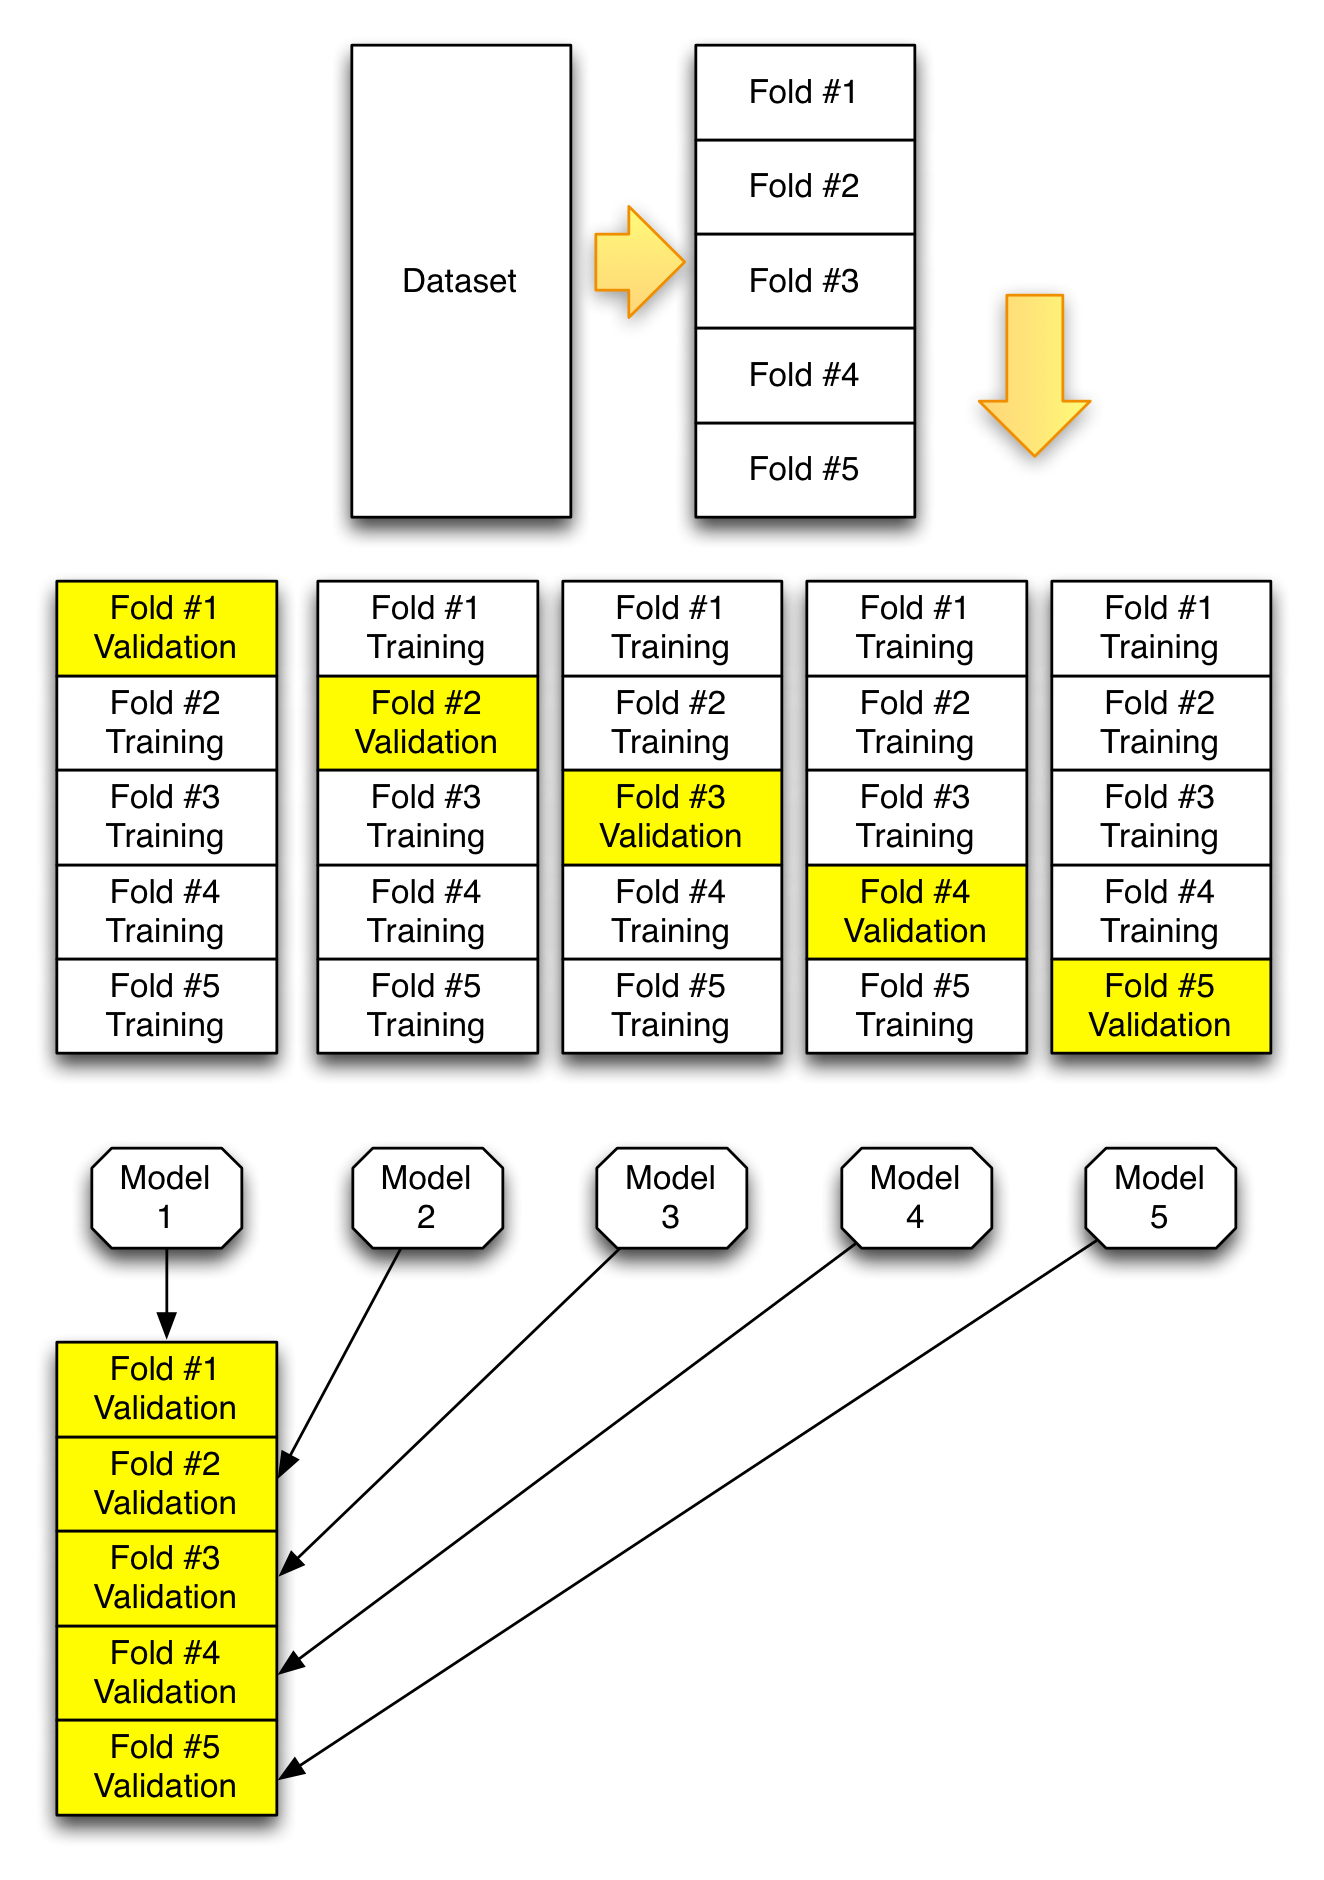

Важно отметить, что у каждого фолда будет своя модель нейронной сети.

Чтобы генерировать прогнозы для новых данных, отсутствующих в обучающем наборе, прогнозы из моделей фолд можно обрабатывать несколькими способами:

* Выбрать модель с наивысшим скором (score) в качестве окончательной модели. Скором принято называть конечную оценку модели не зависимо от выбранной метрики для оценки.
* Предварительно установить новые данные для пяти моделей (по одному для каждого фолда) и усреднить результат.
* Обучить новую модель на всём наборе данных, используя те же настройки (гиперпараметры), что и при перекрестной проверке: то же число эпох и та же структура слоёв. И конечно же, не забыть отложить контрольный образец для оценки.

### Задача о пассажирах Титаника

Метод K-Fold есть в библиотеке sklearn. Чтобы его лучше понять, рассмотрим популярную задачу на Kaggle, посвящённую пассажирам Титаника. Для этого загрузим датасет, который содержит данные пассажиров корабля. Цель задачи — построить модель, которая лучшим образом сможет предсказать, остался ли произвольный пассажир в живых или нет.

Для начала загрузим и распакуем датасет. Будем использовать только обучающую выборку.

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/titanic.zip

--2024-11-01 12:15:21--  https://storage.yandexcloud.net/academy.ai/titanic.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34877 (34K) [application/zip]
Saving to: ‘titanic.zip’

titanic.zip         100%[===================>]  34.06K   112KB/s    in 0.3s    

2024-11-01 12:15:23 (112 KB/s) - ‘titanic.zip’ saved [34877/34877]



In [ ]:
# Распаковываем датасет
!unzip -o -q titanic.zip -d titanic

Text(0.5, 1.0, 'Тепловая карта отсутствующих значений')

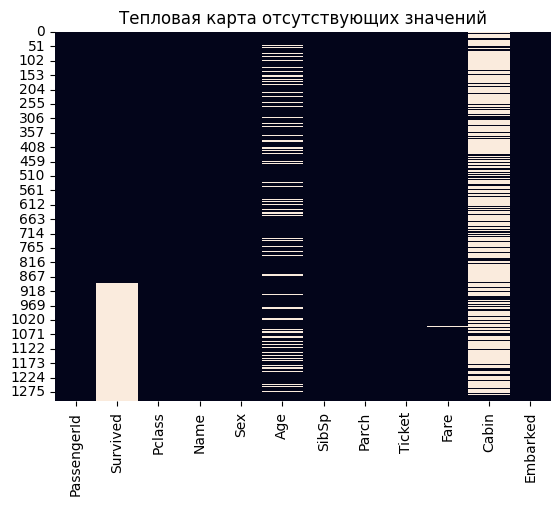

In [ ]:
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
%matplotlib inline

# Создаём DataFrame из датасетов

# Для тренировочного набора
df_train = pd.read_csv(
    "./titanic/train.csv")

# Для контрольного набора
df_test = pd.read_csv(
    "./titanic/test.csv")

# Объединим датасеты, так как нам их всеравно приводить к одной форме
df = pd.concat([df_train, df_test], ignore_index=True, sort = False)

# Для выявления пропусков в данных
# построим тепловую карту отсутствующих значений
sns.heatmap(df.isnull(), cbar = False).set_title("Тепловая карта отсутствующих значений")

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,418
Pclass,0
Name,0
Sex,0
Age,263
SibSp,0
Parch,0
Ticket,0
Fare,1


В датасете было выявлено несколько столбцов, в которых отсутствовали значения. Признак «Cabin» имел 1014 пропущенных значений. Столбец «Survived» содержит 418 пропущенных значений. «Fare» - один пропуск. Столбец «Embarked», который отображал пункт посадки пассажиров, имел всего 2 пропущенных значения, а в признаке «Age» было 263 пропущенных значения.

Далее, определим категориальные признаки, для этого посмотрим на количество уникальных значений в каждом столбце.

In [ ]:
df.nunique()

,0
PassengerId,1309
Survived,2
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281


Признаки «Sex» и «Survived» имеют два возможных значения, а «Embarked» и «Pclass» имеют три возможных значения. Это нам пригодится чуть позже. А сейчас рассмотрим признаки датасета.

#### Признаки набора данных Титаник

Исследуем признаки и роль, которую они сыграли в выживании или гибели пассажира лайнера.

1. **Survived**.
Первый признак, который показывает, выжил ли пассажир или умер. Сравнение показало, что более 60% пассажиров умерли.

In [ ]:
df.Survived.value_counts()

,count
Survived,
0.0,549
1.0,342


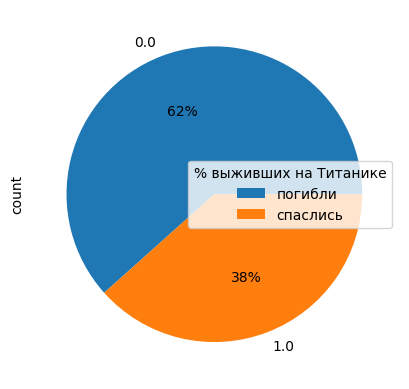

In [ ]:
df.Survived.value_counts().plot(kind='pie', autopct='%1.0f%%').legend(labels=['погибли', 'спаслись'], loc=5).set_title('% выживших на Титанике')

2. **Pclass**.
Этот признак показывает класс, которым следовал пассажир. Пассажиры могли выбрать из трех отдельных классов, а именно: класс 1, класс 2 и класс 3. Третий класс имел наибольшее количество пассажиров, затем класс 2 и класс 1. Количество пассажиров в третьем классе было больше, чем количество пассажиров в первом и втором классе вместе взятых. Вероятность выживания пассажира класса 1 была выше, чем пассажира класса 2 и класса 3.

Text(0.5, 1.0, '% выживших по классам билетов')

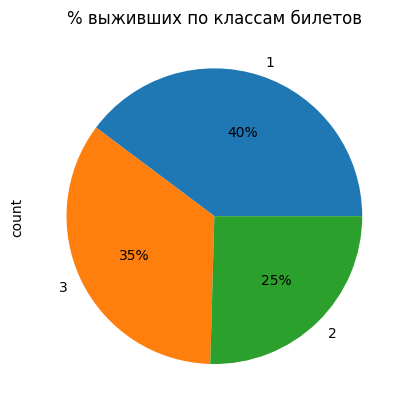

In [ ]:
df[df.Survived==1].Pclass.value_counts().plot(kind='pie', autopct='%1.0f%%').set_title('% выживших по классам билетов')

3. **Sex**.
Примерно 64% пассажиров составляли мужчины, а остальные 36% — женщины. Тем не менее, процент выживших женщин был выше, чем число выживших мужчин.

Survived
False    734
True     109
Name: count, dtype: int64
1309


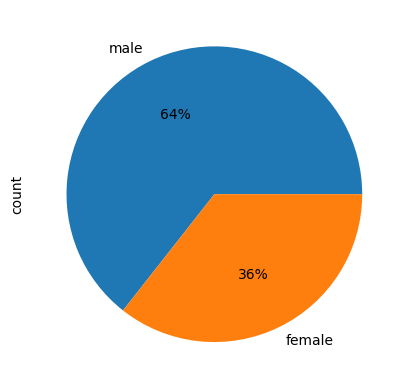

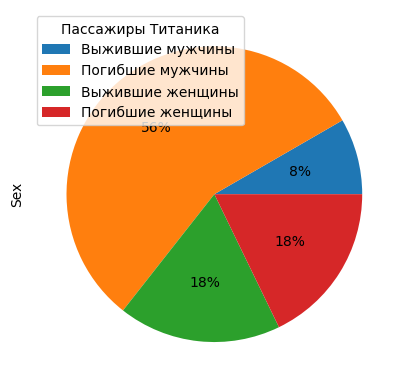

In [ ]:
df.Sex.value_counts().plot.pie(autopct='%1.0f%%')
print((df[df.Sex == 'male'].Survived == 1).value_counts())

male_dec,   male_surv    = (df[df.Sex == 'male'].Survived == 1).value_counts()
female_dec, female_surv  = (df[df.Sex == 'female'].Survived == 1).value_counts()

print(male_surv+male_dec+female_surv+female_dec)

sex_perc_df = pd.DataFrame(
    { "Sex": [male_surv, male_dec, female_surv, female_dec]})
sex_perc_df.plot.pie(y="Sex", autopct='%1.0f%%', labels=None).legend(loc=2, labels=['Выжившие мужчины', 'Погибшие мужчины', 'Выжившие женщины', 'Погибшие женщины']) \
.set_title("Пассажиры Титаника")

4. **Age**.
Самому молодому путешественнику на борту было около двух месяцев, а самому старшему — 80 лет. Средний возраст пассажиров на борту был чуть менее 30 лет. Большая часть детей в возрасте до 10 лет выжила. В любой другой возрастной группе число жертв было выше, чем число выживших. Более 140 человек в возрастной группе 20-30 лет погибли в сравнении с примерно 80 выжившими того же возраста.

In [ ]:
# В качестве разминки получите визуальное подтверждение сказанного в виде графика или таблицы

5. **SibSp**.
SibSp — это число братьев, сестер или супругов на борту у человека. Максимум 8 братьев и сестер путешествовали вместе с одним из путешественников. Более 90% людей путешествовали в одиночку или с одним из своих братьев и сестер или супругом. Шансы на выживание резко падали, если кто-то ездил с более чем двумя родными.

In [ ]:
# В качестве разминки получите визуальное подтверждение сказанного в виде графика или таблицы

6. **Parch**.
Подобно SibSp, этот признак содержит количество родителей или детей, с которыми путешествовал каждый пассажир. Максимум 9 родителей/детей путешествовали вместе с одним из пассажиров.

In [ ]:
# В качестве разминки получите визуальное подтверждение сказанного в виде графика или таблицы

Для хранения суммарных значений `Parch` и `SibSp` добавим  столбец `Family`.



In [ ]:
df['Family'] = df.Parch + df.SibSp

Шансы на выживание резко возрастали, когда путешественник путешествовал один. Поэтому создадим другой столбец `Is_Alone` и присвоим значение `True`, если значение в столбце `Family` было 0.

In [ ]:
df['Is_Alone'] = df.Family == 0

7. **Fare**.
Если разделить тариф на четыре категории, то будет видно, что существует тесная связь между стоимостью тарифа и выживанием. Чем больше заплатит пассажир, тем выше будут его шансы на выживание. Разделение произведем на 4 группы (Low, Mid, High, Top) с помощью метода Pandas `cut()`. Но для начала заполним одно пропущенное значение в данных нулем.

In [ ]:
df.Fare.fillna(0., inplace = True)

<ipython-input-30-32b3b315cc72>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Fare.fillna(0., inplace = True)


Взглянем на статистику распределения значений тарифов:

In [ ]:
df.Fare.describe()

,Fare
count,1309.000000
mean,33.270043
std,51.747063
min,0.000000
25%,7.895800
50%,14.454200
75%,31.275000
max,512.329200


С помощью функции `cut()` мы хотим взять тариф, посмотреть на его статистическое распределение значений, определить ключевые точки этого распределения (`min`, `25%`, `50%`, `75%`, `max`), по ним нарезать интервалы:

In [ ]:
pd.cut(df['Fare'], bins=[0, 7.9, 14.45, 31.28, 512.4], include_lowest=True).value_counts()

,count
Fare,
"(-0.001, 7.9]",338
"(14.45, 31.28]",338
"(31.28, 512.4]",323
"(7.9, 14.45]",310


В математике при обозначении интервалов:
 `(` - круглые скобки, говорят о том, что значение не включается в диапазон, а
 `]` - квадратная скобка, говорит о включении значения в диапазон. Поэтому мы указали параметр `include_lowest` равный `True`, и метод `cut()` расширил интервал на одну тысячную в отрицательную область, чтобы первая точка равного нуля точно вошла в интервал.

 Таким образом мы получили 4, более или менее, одинаковых интервала по числу значений в них, и хотим присвоить этим интервалам имена (`Low`, `Mid`, `High`, `Top`). Имена интервалов поместим в новый столбец `Fare_Category`:

In [ ]:
df['Fare_Category'] = pd.cut(df['Fare'], bins=[0, 7.9, 14.45, 31.28, 512.4], include_lowest=True, labels=['Low','Mid', 'High','Top'])

In [ ]:
# В качестве разминки докажите с помощью диаграммы, что чем выше тариф от Low до Top, тем выше шанс на выживание

8. **Embarked**.
Этот столбец хранит информацию о порте посадки пассажира. Есть три возможных значения для Embarked -  Саутгемптон, Шербург и Куинстаун (S, C, Q). Более 70% людей сели в Саутгемптон. Чуть менее 20% сели на борт из Шербура, а остальные — из Квинстауна. Люди, которые сели в порте Шербург, имели более высокие шансы на выживание, чем люди, которые сели в портах Саутгемптон или Квинстаун.

In [ ]:
# В качестве разминки получите визуальное подтверждение сказанного в виде графика или таблицы

9. **Ticket**. Поскольку информация о номере билетах не предоставляет никакой дополнительной информации, мы ее не будем рассматривать и просто удалим столбец.


10. **Cabin**. Поскольку информация о каютах не несет никакой дополнительной информации, имеет много пропусков, и может только запутать нашу модель, то мы ее не будем рассматривать и просто удалим столбец.

11. **PassengerId** и **Name** - идентификатор пассажира и его имя мы также не будем использовать в модели. Из имени мы только извлечем префикс для обращения (например, Mr, Miss, Mrs), но это немного позже.   

#### Заполнение пропущенных данных

Поскольку у `Embarked` было только два пропущенных значения и наибольшее количество пассажиров отправлялось из Саутгемптона, вероятность посадки в Саутгемптоне выше. Поэтому мы заполняем недостающие значения Саутгемптоном.

Однако в задачах, у нас будут не такие идеальные условия, поэтому рекомендуется найти моду (наиболее часто встречающийся элемент в выборке) и им заполнить пропуски.

Найдем моду:


In [ ]:
df.Embarked.mode()[0]

'S'

Заполним ей пропуски:

In [ ]:
df.Embarked.fillna(df.Embarked.mode()[0], inplace = True)

<ipython-input-37-e2e90d66b112>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Embarked.fillna(df.Embarked.mode()[0], inplace = True)


Столбец `Age` самый сложный для заполнения и имеет целых 263 пропущенных значения.

Воспользуемся следующим алгоритмом для его заполнения:

1. Классифицируем людей на основе их имен (например, Mr, Miss, Mrs)




In [ ]:
df.Name.apply(lambda name: name.split(',')[1].split('.')[0].strip()).unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer', 'Dona'], dtype=object)

In [ ]:
df['Salutation'] = df.Name.apply(lambda name: name.split(',')[1].split('.')[0].strip())

2. Сгруппируем эти названия по группам `Sex`, `Pclass`


In [ ]:
group = df.groupby(['Sex', 'Pclass'], group_keys=True)

3. Медиану групп подставим в пропущенные строки.

In [ ]:
group['Age'].apply(lambda x: x.fillna(x.median()))
df['Age'].fillna(df.Age.median(), inplace = True)

<ipython-input-41-6335b00e744a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.Age.median(), inplace = True)


4. Разобьем возраст на диапазоны по 10 лет:

In [ ]:
df['Age_Range'] = pd.cut(df['Age'],
                         bins=[0, 10, 20, 30, 40, 50, 60, 70, 80],
                         labels=[10, 20, 30, 40, 50, 60, 70, 80],
                         include_lowest=True)

#### Кодирование категориальных признаков

Поскольку текстовые данные плохо сочетаются с алгоритмами машинного обучения, их необходимо преобразовать в числовые данные.

Для столбцов, которые содержат только 2 значения принято использовать кодировщик `LabelEncoder()`. Данный подход мы используем для столбцов `Sex` и `Is_Alone`.

Текстовые данные, которые в колонке повторяются много раз и их можно разделить на смысловые категории, принято называть категориальными данными. Для таких данных мы будем использовать функцию Pandas `get_dummies`, которая добавляет столбцы, соответствующие всем уникальным значениям столбца. Так например, для столбца `Embarked` возможны только 3 значения C, S, Q, и метод `get_dummies` создал бы три различных столбца и назначил бы значения 0 или 1 в зависимости от соответствия значения этому столбцу.

Созданные переменные (`Emb_C`,	`Emb_Q`,	`Emb_S`), принято называть фиктивными:

In [ ]:
pd.get_dummies(df.Embarked, prefix="Emb")

,Emb_C,Emb_Q,Emb_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
1304,False,False,True
1305,True,False,False
1306,False,False,True
1307,False,False,True


Как правило в фиктивных переменных удаляют первый столбец, так как все нули в остальных, означает, что он заполнен. Тем самым борются с избыточными данными. Мы поступим также.

In [ ]:
pd.get_dummies(df.Embarked, prefix="Emb", drop_first = True)

,Emb_Q,Emb_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
1304,False,True
1305,False,False
1306,False,True
1307,False,True


Закодируем все необходимые признаки:

In [ ]:
from sklearn.preprocessing import LabelEncoder

df = pd.concat([
    df, pd.get_dummies(df.Age_Range, prefix="Age_Range"),
        pd.get_dummies(df.Embarked, prefix="Emb", drop_first = True),
        pd.get_dummies(df.Salutation, prefix="Title", drop_first = True),
        pd.get_dummies(df.Fare_Category, prefix="Fare", drop_first = True),
        pd.get_dummies(df.Pclass, prefix="Class", drop_first = True)],
    axis=1)

df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['Is_Alone'] = LabelEncoder().fit_transform(df['Is_Alone'])

И удалим лишние столбцы, не участвующие в обучении:

In [ ]:
df.drop(['PassengerId', 'Pclass', 'Fare','Cabin', 'Fare_Category','Name','Salutation', 'Ticket','Embarked', 'Age_Range', 'SibSp', 'Parch'], axis=1, inplace=True)


Таким образом у нас остались следующие столбцы:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Survived            891 non-null    float64
 1   Sex                 1309 non-null   int64  
 2   Age                 1309 non-null   float64
 3   Family              1309 non-null   int64  
 4   Is_Alone            1309 non-null   int64  
 5   Age_Range_10        1309 non-null   bool   
 6   Age_Range_20        1309 non-null   bool   
 7   Age_Range_30        1309 non-null   bool   
 8   Age_Range_40        1309 non-null   bool   
 9   Age_Range_50        1309 non-null   bool   
 10  Age_Range_60        1309 non-null   bool   
 11  Age_Range_70        1309 non-null   bool   
 12  Age_Range_80        1309 non-null   bool   
 13  Emb_Q               1309 non-null   bool   
 14  Emb_S               1309 non-null   bool   
 15  Title_Col           1309 non-null   bool   
 16  Title_

### Задачи регрессии и классификации с K-Fold перекрестной проверкой

Регрессия и классификация обрабатываются несколько по-разному в отношении перекрестной проверки. Регрессия - это более простой случай, когда вы можете разбить набор данных на K фолдов, не обращая особого внимания на то, куда попадает каждый элемент. Для регрессии элементы данных должны попадать в фолд как можно более случайным образом. Также важно помнить, что не в каждом фолде обязательно будет одинаковое количество элементов данных. Не всегда возможно равномерно разделить набор данных на K фолдов. Для перекрестной проверки регрессии мы будем использовать класс Scikit-Learn KFold.

Перекрестная проверка для классификации также может использовать объект KFold. Однако этот метод не гарантирует, что баланс классов остается таким же в каждом фолде, как в первоначальном. Баланс классов, на которых обучалась модель, должен оставаться таким же (или похожим) на обучающий набор. Отклонение в распределении - одна из наиболее важных вещей, которую необходимо отслеживать после того, как обученная модель была введена в фактическое использование.

Из-за этого мы должны убедиться, что перекрестная проверка сама по себе не приводит к непреднамеренному сдвигу. Этот метод называется стратифицированной выборкой и выполняется с помощью объекта Scikit-Learn StratifiedKFold вместо KFold. То есть если перед вами стоит задача классификации необходимо использовать StratifiedKFold.

Вы должны использовать следующие два объекта в Scikit-Learn:

* **KFold** при решении задачи регрессии.
* **StratifiedKFold** при решении задачи классификации.


#### Регрессия с K-Fold перекрестной проверкой

В данном блоке, мы обучим модель предсказывать возраст пассажира Титаника по остальным признакам. Так как возраст - это число, то предсказание числа - это задача регрессии. Мы будем использовать 5-фолдовую кросс-валидацию. Конечную оценку модели мы будем вычислять на сгенерированных прогнозируемых значениях вне обучающей выборки.

**ВАЖНО**. Обратите внимание, что наша модель должна выдавать результат - одно число, поэтому выходной слой содержит один нейрон с линейной функцией активации, которая может принимать значение от 0 и до бесконечности. Для задач регрессии наиболее часто используют КОМБО:
* функция активации в последнем слое - линейная
* функция потерь - `mean_squared_error` (среднеквадратичное отклонение)
* оптимизатор - `adam`.



In [ ]:
train_data = df.dropna()

# Удаляем колонки с возрастом из признаков
# Если их оставить то модель будет точно знать возрастной диапазон пассажира
# Что исказит результат
x_columns = train_data.columns.drop('Age') \
  .drop(['Age_Range_10', 'Age_Range_20', 'Age_Range_30',
         'Age_Range_40', 'Age_Range_50', 'Age_Range_60',
         'Age_Range_70','Age_Range_80'])
x = train_data[x_columns].values
y = train_data['Age'].values

In [ ]:
EPOCHS=200

import pandas as pd
import os
import numpy as np
from sklearn import metrics
from scipy.stats import zscore
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.layers import Dense, Activation, Input

# Используем KFold для задачи регрессии
kf = KFold(5, shuffle=True, random_state=42)
oos_y = [] # Собираем метки контрольной выборки
oos_pred = [] # Собираем предсказанные метки на контрольной выборке

fold = 0
for train, test in kf.split(x):
    fold+=1
    print(f"Fold #{fold}")

    x_train = np.asarray(x[train]).astype('float32')
    x_test = np.asarray(x[test]).astype('float32')

    y_train = np.asarray(y[train]).astype('float32')
    y_test = np.asarray(y[test]).astype('float32')

    model = Sequential()
    model.add(Input(shape=(x.shape[1],)))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(10, activation='relu'))
    model.add(Dense(1))
    # Функция потерь - MSE (средне квадратичное отклонение)
    model.compile(loss='mean_squared_error', optimizer='adam')

    model.fit(x_train, y_train, verbose=0, epochs=EPOCHS)

    # Предсказываем на выборке не участвующей в обучении
    pred = model.predict(x_test)

    # Заполняем списки (реальными и предсказанными) данными, по которым не училась модель
    oos_y.append(y_test)
    oos_pred.append(pred)

    # Измерение RMSE для фолда по предсказанным данным
    score = np.sqrt(metrics.mean_squared_error(pred, y_test))
    print(f"Fold score (RMSE): {score}")

# Вычисляем ошибку предсказания на всей накопленной в фолдах контрольной выборке.
oos_y = np.concatenate(oos_y)
oos_pred = np.concatenate(oos_pred)
score = np.sqrt(metrics.mean_squared_error(oos_pred, oos_y))
print(f"Итоговый score на контрольной выборке (RMSE): {score}")

Fold #1
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fold score (RMSE): 10.958333015441895
Fold #2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Fold score (RMSE): 9.867086410522461
Fold #3


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fold score (RMSE): 10.748878479003906
Fold #4


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Fold score (RMSE): 10.680383682250977
Fold #5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Fold score (RMSE): 10.26265811920166
Итоговый score на контрольной выборке (RMSE): 10.51122760772705


Результат для RMSE (корень квадратный из среднеквадратичной ошибки) равный примерно 10, говорит о том, что наша модель с ошибкой в 10 лет может определить возраст пассажира Титаника.

#### Классификация со стратификационной  регрессии вне выборки с K-Fold перекрестной проверкой

В данном блоке, мы обучим модель предсказывать выжил ли пассажир Титаника. Это задача бинарной классификации, однако мы ее решим в общем виде, как мультиклассовую классификацию, как более общий пример.


**ВАЖНО**. Для задач мультиклассовой классификации выходной слой нейронной сети должен состоять из числа нейронов равного числу классов. В нашем случае класса 2: выжил пассажир или нет. Функция активации в последнем слое должна быть `softmax`, с которой хорошо работают функция потерь 	    `categorical_crossentropy` и оптимизатор `adam`. Это трио из функции активации, функции потерь и оптимизатора вам будет встречаться в большинстве задач мультиклассовой оптимизации. Их сочетание стоит запомнить!

Пока вы только учитесь в любой непонятной ситуации используйте оптимизатор `Adam`. В качестве функций активаций скрытых слоев - `relu`.

Для задач классификации используется объект `StratifiedKFold` вместо объекта `KFold`, этот метод гарантирует, что процентное соотношение каждого класса остается одинаковым во всех фолдах.

In [ ]:
# Удаляем колонку Age (она нам была нужна для предыдущей задачи)
x_columns = train_data.columns.drop('Survived').drop('Age')
x = train_data[x_columns].values

# В качестве меток используем признак Survived (выжил пассажир или нет)
y = pd.get_dummies(train_data['Survived']).values

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from keras.models import Sequential
from keras.layers import Dense, Activation, Input

# Для задач классификации используют StratifiedKFold
kf = StratifiedKFold(5, shuffle=True, random_state=42)

oos_y = []
oos_pred = []
fold = 0

for train, test in kf.split(x, train_data['Survived']):
    fold+=1
    print(f"Fold #{fold}")

    x_train = np.asarray(x[train]).astype('float32')
    x_test = np.asarray(x[test]).astype('float32')

    y_train = np.asarray(y[train]).astype('float32')
    y_test = np.asarray(y[test]).astype('float32')

    model = Sequential()
    model.add(Input(shape=(x.shape[1],)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(y.shape[1],activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam')

    model.fit(x_train, y_train, verbose=0, epochs=EPOCHS)

    # Предсказываем на выборке не участвующей в обучении
    pred = model.predict(x_test)
    # выбираем класс с максимальной вероятностью
    pred = np.argmax(pred, axis=1)

    # Заполняем списки (реальными и предсказанными) данными, по которым не училась модель
    oos_y.append(y_test)
    oos_pred.append(pred)

    # Переводим "разряженный" класс в номер класса
    y_compare = np.argmax(y_test, axis=1)

    # Вычислим точность
    score = metrics.accuracy_score(y_compare, pred)
    print(f"Fold score (accuracy): {score}")

# Вычисляем ошибку предсказания на всей накопленной в фолдах контрольной выборке.
oos_y = np.concatenate(oos_y)
oos_pred = np.concatenate(oos_pred)
oos_y_compare = np.argmax(oos_y, axis=1)

score = metrics.accuracy_score(oos_y_compare, oos_pred)
print(f"Итоговый score (accuracy): {score}")


Fold #1
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold score (accuracy): 0.7821229050279329
Fold #2
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold score (accuracy): 0.8202247191011236
Fold #3
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fold score (accuracy): 0.8202247191011236
Fold #4
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Fold score (accuracy): 0.8539325842696629
Fold #5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold score (accuracy): 0.8202247191011236
Итоговый score (accuracy): 0.819304152637486


Здесь в качестве метрики мы использовали `accuracy` (точность). Которая показывает, что наша модель способна предсказывать с вероятностью около 83% выжил пассажир Титаника или нет.

#### Кросс-валидация в классическом машинном обучении (ML)

Несмотря на то, что курс в основном посвящен DL (глубокому обучению), мы все же периодически будем захватывать и ML (классическое машинное обучение). В вашем арсенале должны быть оба подхода, ведь машинное обучение куда шире, чем узкая специальность нейронщика. Поэтому давайте предскажем выживет ли пассажир Титаника или нет с помощью классического метода "случайный лес" (RandomForestClassifier):

In [ ]:
# Данные для предсказания
X_to_be_predicted = df[df.Survived.isnull()]
X_to_be_predicted = X_to_be_predicted.drop(['Survived'], axis = 1)

#Данные для обучения
train_data = df
train_data = train_data.dropna()
feature_train = train_data['Survived']
label_train  = train_data.drop(['Survived'], axis = 1)
train_data.shape

(891, 37)

Кросс-валидационная оценка точности для "случайного леса": 83.43%


Text(0.5, 1.05, 'Матрица ошибок для случайного леса')

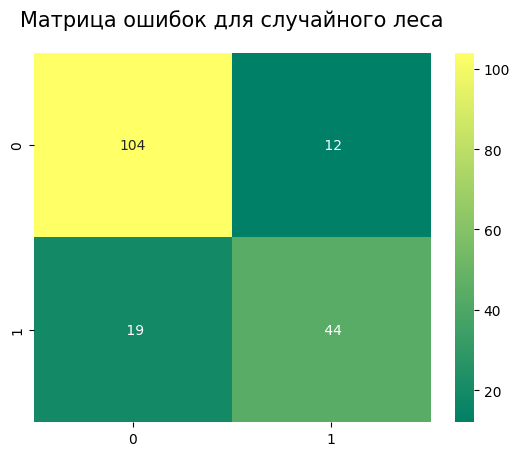

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

clf = RandomForestClassifier(criterion='entropy',
                             n_estimators=700,
                             min_samples_split=10,
                             min_samples_leaf=1,

                             oob_score=True,
                             random_state=1,
                             n_jobs=-1)
x_train, x_test, y_train, y_test = train_test_split(label_train, feature_train, test_size=0.2)


# Модель clf обучается в процессе валидации, на вход подаётся до обучения
# Функция cross_val_score создает 5 фолдов и возвращает список оценок, в данном случае accuracy
result_rf = cross_val_score(clf, x_train, y_train, cv=5, scoring='accuracy')
print('Кросс-валидационная оценка точности для "случайного леса": '+repr(round(result_rf.mean() * 100, 2)) + "%")

# возвращает для каждого элемента прогноз
y_pred = cross_val_predict(clf, x_test, y_test, cv=5)

# Отобразим матрицу ошибок
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='3.0f', cmap="summer")
plt.title('Матрица ошибок для случайного леса', y=1.05, size=15)

Чтобы лучше понять проблему переобучения и недообучения в машинном обучении рассмотрим задачу с отзывами к фильмам в [следующей части урока](https://colab.research.google.com/drive/1VWkA2xBTwWreo3DTdiMkio-RfQIvlXBl).